# 03 — Embeddings + Clustering — Black Basta

Genera embeddings de mensajes con `qwen3-embedding` (4096 dims).  
Con solo 49 actores podemos añadir una sección extra:  
**comparativa directa con los perfiles de Conti** (si están disponibles).

Produce:
- `data/processed/bb_message_embeddings.npy` — matriz (N, 4096)
- `data/processed/bb_actor_embeddings.parquet` — centroide por actor + cluster + rol
- `data/processed/bb_sample_with_embeddings.parquet` — muestra + cluster por mensaje

## 0. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('src').resolve()))

import json
import numpy as np
import pandas as pd
import ollama
import umap
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics.pairwise import cosine_similarity
from tqdm.auto import tqdm

PROCESSED_DIR  = Path('../data/processed')
SAMPLE_IN      = PROCESSED_DIR / 'bb_sample_classified.parquet'
PROFILES_IN    = PROCESSED_DIR / 'bb_actor_profiles.json'
EMBEDDINGS_NPY = PROCESSED_DIR / 'bb_message_embeddings.npy'
ACTOR_EMB_OUT  = PROCESSED_DIR / 'bb_actor_embeddings.parquet'
SAMPLE_OUT     = PROCESSED_DIR / 'bb_sample_with_embeddings.parquet'

EMBED_MODEL = 'qwen3-embedding'
EMBED_DIMS  = 4096
BATCH_SIZE  = 32

for p in [SAMPLE_IN, PROFILES_IN]:
    assert p.exists(), f'No se encuentra {p} — ejecuta primero el notebook 02'
print('Setup OK')

/home/drjekyll/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Setup OK


## 1. Cargar datos

In [2]:
sample = pd.read_parquet(SAMPLE_IN)
with open(PROFILES_IN, encoding='utf-8') as f:
    profiles = json.load(f)

print(f'Mensajes : {len(sample):,}')
print(f'Actores  : {sample.username.nunique()}')
print(f'\nCategorías:\n{sample.category.value_counts().to_string()}')

Mensajes : 3,598
Actores  : 47

Categorías:
category
technical         1054
comms             1051
unknown            777
operational        543
financial          122
organizational      51


## 2. Generar embeddings

In [3]:
if EMBEDDINGS_NPY.exists():
    embeddings = np.load(EMBEDDINGS_NPY)
    assert len(embeddings) == len(sample)
    print(f'Embeddings cargados desde caché: {embeddings.shape}')
else:
    texts = sample['message'].str.strip().tolist()
    embeddings = np.zeros((len(texts), EMBED_DIMS), dtype=np.float32)

    for start in tqdm(range(0, len(texts), BATCH_SIZE), desc='Generando embeddings'):
        batch = texts[start:start + BATCH_SIZE]
        resp  = ollama.embed(model=EMBED_MODEL, input=batch)
        for j, emb in enumerate(resp.embeddings):
            embeddings[start + j] = emb

    np.save(EMBEDDINGS_NPY, embeddings)
    print(f'Guardado → {EMBEDDINGS_NPY}  {embeddings.shape}')

Generando embeddings: 100%|███████████████████| 113/113 [01:42<00:00,  1.10it/s]

Guardado → ../data/processed/bb_message_embeddings.npy  (3598, 4096)


## 3. Centroides por actor

In [4]:
sample_emb = sample.copy()
sample_emb['emb_idx'] = range(len(sample_emb))

actor_centroids = {}
for actor, group in sample_emb.groupby('username'):
    idxs = group['emb_idx'].tolist()
    actor_centroids[actor] = embeddings[idxs].mean(axis=0)

actor_matrix = np.array(list(actor_centroids.values()))
actor_names  = list(actor_centroids.keys())
print(f'Centroides: {actor_matrix.shape}')

Centroides: (47, 4096)


## 4. UMAP + HDBSCAN

In [5]:
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=10,   # menor que Conti (49 actores vs 485)
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

print('Ajustando UMAP...')
msg_2d   = reducer.fit_transform(embeddings)
actor_2d = reducer.transform(actor_matrix)

clusterer = hdbscan.HDBSCAN(min_cluster_size=3, min_samples=2, metric='euclidean')
actor_clusters = clusterer.fit_predict(actor_2d)

n_clusters = len(set(actor_clusters)) - (1 if -1 in actor_clusters else 0)
n_noise    = (actor_clusters == -1).sum()
print(f'Clusters: {n_clusters}  |  Ruido: {n_noise} actores')

for cl in sorted(set(actor_clusters)):
    members = [actor_names[i] for i, c in enumerate(actor_clusters) if c == cl]
    label   = 'ruido' if cl == -1 else f'cluster {cl}'
    print(f'  {label:<12}: {members}')

/home/drjekyll/.local/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Ajustando UMAP...
Clusters: 3  |  Ruido: 4 actores
  ruido       : ['arslanshabbirmalik', 'username777', 'usernameboy', 'usernamehh']
  cluster 0   : ['adm', 'burito', 'cameron777', 'chuck', 'iamnurnazarov', 'lincoln', 'manager361', 'manager880', 'mel', 'n3auxaxl', 'ng', 'princehorn', 'ssd', 'ugw', 'usernameff', 'usernamegg', 'usernamenn', 'usernamevv']
  cluster 1   : ['blood', 'cob_crypt_ward', 'colin', 'lapa', 'nickolas', 'staffer', 'sunortla', 'timber', 'tinker', 'u123', 'usernamehunter', 'usernamenn1', 'usernameugway', 'usernameyy', 'w']
  cluster 2   : ['muaddib6', 'usernamecc', 'usernamedd', 'usernamejj', 'usernamemm', 'usernamess', 'usernamett', 'usernameww', 'usernamexx', 'usernamezz']


## 5. Visualizaciones

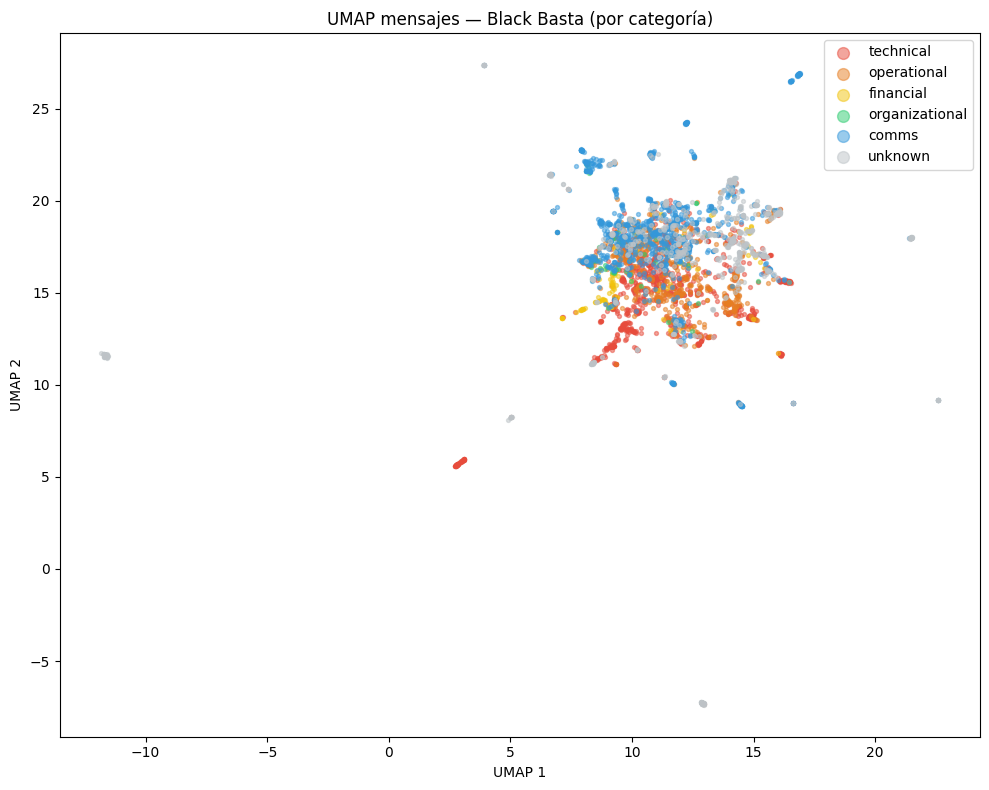

In [6]:
cat_color = {
    'technical':      '#e74c3c',
    'operational':    '#e67e22',
    'financial':      '#f1c40f',
    'organizational': '#2ecc71',
    'comms':          '#3498db',
    'unknown':        '#bdc3c7',
}

fig, ax = plt.subplots(figsize=(10, 8))
for cat, color in cat_color.items():
    mask = sample['category'] == cat
    ax.scatter(msg_2d[mask, 0], msg_2d[mask, 1],
               c=color, s=8, alpha=0.5, label=cat, rasterized=True)
ax.set_title('UMAP mensajes — Black Basta (por categoría)')
ax.legend(markerscale=3)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

/tmp/ipykernel_65711/2162903423.py:8: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],


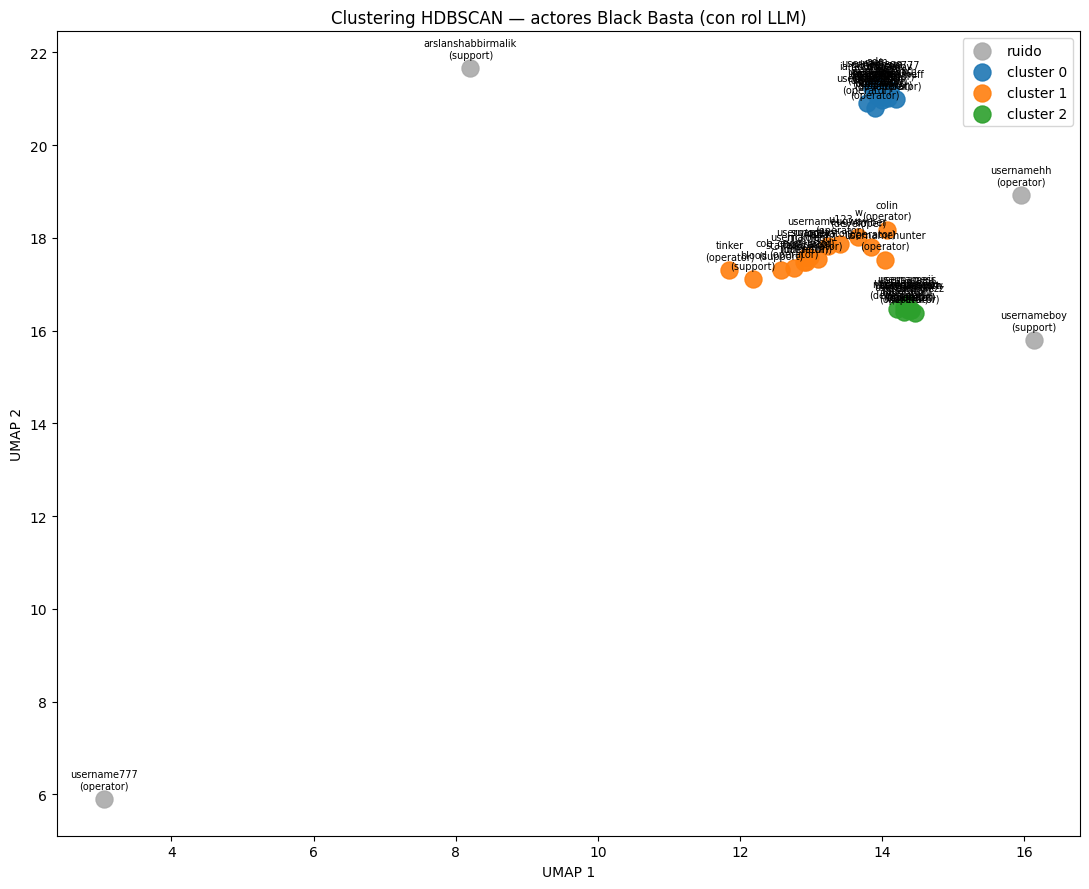

In [7]:
palette = cm.tab10.colors

fig, ax = plt.subplots(figsize=(11, 9))
for cl in sorted(set(actor_clusters)):
    mask  = actor_clusters == cl
    color = '#aaaaaa' if cl == -1 else palette[cl % len(palette)]
    label = 'ruido' if cl == -1 else f'cluster {cl}'
    ax.scatter(actor_2d[mask, 0], actor_2d[mask, 1],
               c=color, s=150, alpha=0.9, label=label, zorder=3)

for i, name in enumerate(actor_names):
    role = profiles.get(name, {}).get('role', '')
    ax.annotate(f'{name}\n({role})', (actor_2d[i, 0], actor_2d[i, 1]),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 6), textcoords='offset points')

ax.set_title('Clustering HDBSCAN — actores Black Basta (con rol LLM)')
ax.legend()
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## 6. Similitud coseno entre actores

In [8]:
sim_matrix = cosine_similarity(actor_matrix)
np.fill_diagonal(sim_matrix, -1)

print('=== TOP 3 MÁS SIMILARES POR ACTOR ===')
for i, actor in enumerate(actor_names):
    top3_idx = np.argsort(sim_matrix[i])[::-1][:3]
    top3 = [(actor_names[j], sim_matrix[i, j]) for j in top3_idx]
    pairs = ', '.join(f'{a} ({s:.3f})' for a, s in top3)
    role  = profiles.get(actor, {}).get('role', '?')
    print(f'  {actor:<20} [{role:<15}] → {pairs}')

=== TOP 3 MÁS SIMILARES POR ACTOR ===
  adm                  [operator       ] → chuck (0.989), u123 (0.985), lincoln (0.985)
  arslanshabbirmalik   [support        ] → manager361 (0.919), manager880 (0.913), iamnurnazarov (0.899)
  blood                [support        ] → chuck (0.979), u123 (0.978), usernameugway (0.978)
  burito               [developer      ] → n3auxaxl (0.981), usernameff (0.978), usernamegg (0.978)
  cameron777           [operator       ] → usernamevv (0.976), usernamess (0.974), usernamegg (0.974)
  chuck                [operator       ] → adm (0.989), u123 (0.987), usernamegg (0.984)
  cob_crypt_ward       [operator       ] → usernameyy (0.980), usernamenn (0.979), staffer (0.979)
  colin                [operator       ] → iamnurnazarov (0.936), tinker (0.934), usernameugway (0.934)
  iamnurnazarov        [operator       ] → lincoln (0.979), mel (0.976), ugw (0.975)
  lapa                 [operator       ] → usernameugway (0.986), u123 (0.985), n3auxaxl (0.983)

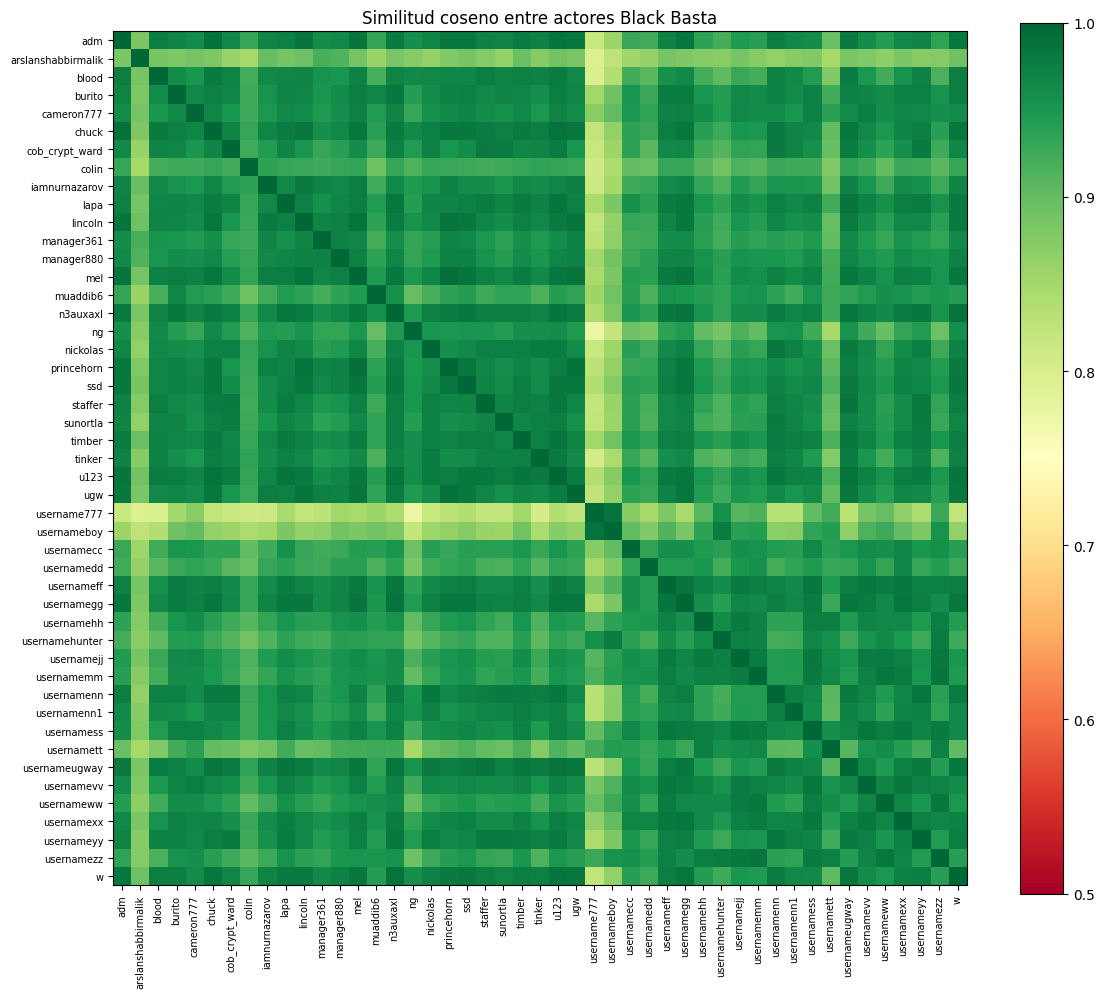

In [9]:
# Heatmap de similitud coseno entre todos los actores
sim_display = cosine_similarity(actor_matrix)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(sim_display, cmap='RdYlGn', vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(actor_names)))
ax.set_xticklabels(actor_names, rotation=90, fontsize=7)
ax.set_yticks(range(len(actor_names)))
ax.set_yticklabels(actor_names, fontsize=7)
ax.set_title('Similitud coseno entre actores Black Basta')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 7. Guardar

In [10]:
actor_to_cluster = dict(zip(actor_names, actor_clusters))
sample_out = sample.copy()
sample_out['cluster'] = sample_out['username'].map(actor_to_cluster)
sample_out['umap_x']  = msg_2d[:, 0]
sample_out['umap_y']  = msg_2d[:, 1]
sample_out.to_parquet(SAMPLE_OUT, index=False)

actor_df = pd.DataFrame({
    'actor':      actor_names,
    'cluster':    actor_clusters,
    'umap_x':     actor_2d[:, 0],
    'umap_y':     actor_2d[:, 1],
    'llm_role':   [profiles.get(a, {}).get('role', 'unknown') for a in actor_names],
    'llm_conf':   [profiles.get(a, {}).get('confidence', 'low') for a in actor_names],
})
actor_df.to_parquet(ACTOR_EMB_OUT, index=False)

print(f'Muestra con embeddings → {SAMPLE_OUT}')
print(f'Actor embeddings       → {ACTOR_EMB_OUT}')
print(f'Embeddings brutos      → {EMBEDDINGS_NPY}')
print(f'\nResumen: {len(embeddings):,} embeddings | {n_clusters} clusters | {n_noise} en ruido')

Muestra con embeddings → ../data/processed/bb_sample_with_embeddings.parquet
Actor embeddings       → ../data/processed/bb_actor_embeddings.parquet
Embeddings brutos      → ../data/processed/bb_message_embeddings.npy

Resumen: 3,598 embeddings | 3 clusters | 4 en ruido
